# Pipeline NLP — Abstracts do arXiv

## Fase 1 — Pré-processamento

**Corpus:** 5 400 abstracts de 5 categorias do arXiv (`cs.LG`, `stat.ML`, `q-bio.NC`, `econ.EM`, `eess.SP`).

**Produto desta fase:** coluna `tokens_lemma` — sequência de lemas limpos por abstract — que alimenta todas as fases seguintes.

**Etapas:**
1. Carregamento e inspeção inicial
2. Limpeza de LaTeX
3. Tokenização (sentenças e palavras)
4. Remoção de stopwords
5. Stemming (Porter) × Lemmatização (spaCy) — comparação
6. POS tagging
7. Análise de impacto no vocabulário
8. Visualizações

> Execute as células de cima para baixo em ordem.


In [1]:
DOWNLOAD = False  # notebook reads local files only — never touches the network

import os
import re
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns
import spacy
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import sent_tokenize, word_tokenize
from wordcloud import WordCloud

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 4)})
os.makedirs('outputs', exist_ok=True)
print('Setup OK')


Setup OK


## 1.1 Carregamento e Inspeção Inicial


In [2]:
df = pd.read_parquet('data/corpus_raw.parquet')
print(f'Shape: {df.shape}')
df.head(2)


Shape: (5400, 6)


,id,title,abstract,primary_category,authors,published
0,2507.15774,Time Series Forecasting Through the Lens of Dynamics,"While deep learning is facing an homogenization across modalities led by Transformers, they are still challenged by ...",cs.LG,"[Alexis-Raja Brachet, Pierre-Yves Richard and C\'eline Hudelot]",2026-05-15
1,2510.27258,Higher-order Linear Attention,The quadratic cost of scaled dot-product attention is a central obstacle to scaling autoregressive language models t...,cs.LG,"[Yifan Zhang, Zhen Qin, Mengdi Wang, Quanquan Gu]",2026-05-15


In [3]:
print('Abstracts por categoria:')
print(df['primary_category'].value_counts().to_string())
print(f'\nTotal: {len(df)}')


Abstracts por categoria:
primary_category
cs.LG       2000
stat.ML     1200
eess.SP     1200
q-bio.NC     500
econ.EM      500

Total: 5400


In [4]:
df['n_words_raw'] = df['abstract'].str.split().str.len()

print('Estatísticas de comprimento (palavras brutas):')
print(df['n_words_raw'].describe().round(1).to_string())
print()
print('Média por categoria:')
print(df.groupby('primary_category')['n_words_raw'].mean().round(1)
        .sort_values(ascending=False).to_string())


Estatísticas de comprimento (palavras brutas):


count    5400.0
mean      176.7
std        44.1
min        14.0
25%       147.0
50%       176.0
75%       207.0
max       300.0



Média por categoria:


primary_category
q-bio.NC    189.4
cs.LG       182.6
eess.SP     177.7
stat.ML     171.1
econ.EM     151.5


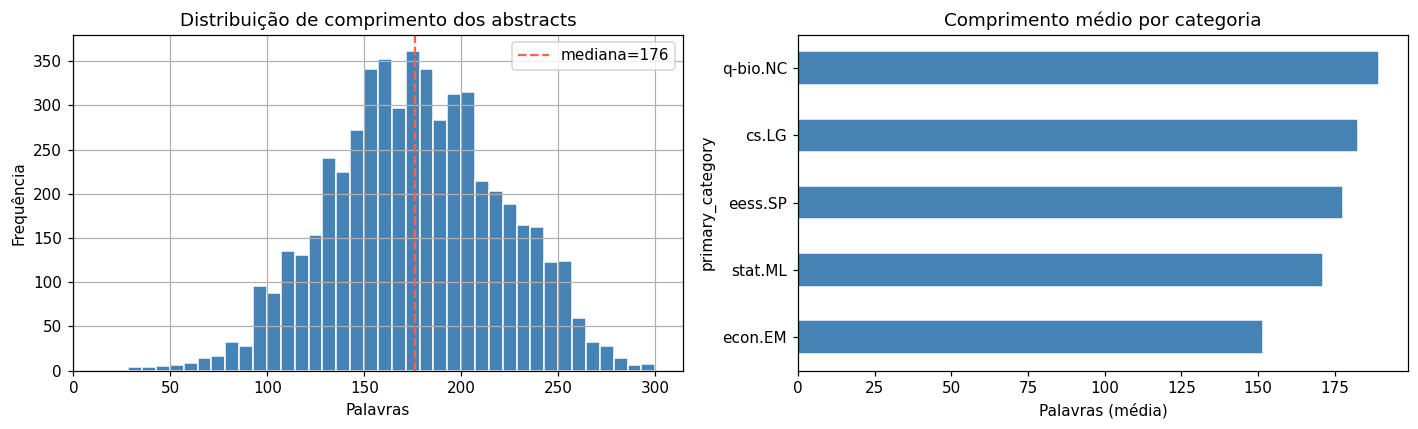

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['n_words_raw'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
med = df['n_words_raw'].median()
axes[0].axvline(med, color='tomato', linestyle='--', label=f'mediana={med:.0f}')
axes[0].set_title('Distribuição de comprimento dos abstracts')
axes[0].set_xlabel('Palavras'); axes[0].set_ylabel('Frequência')
axes[0].legend()

(df.groupby('primary_category')['n_words_raw'].mean()
   .sort_values()
   .plot.barh(ax=axes[1], color='steelblue', edgecolor='white'))
axes[1].set_title('Comprimento médio por categoria')
axes[1].set_xlabel('Palavras (média)')

plt.tight_layout()
plt.savefig('outputs/fig_abstract_lengths.png', bbox_inches='tight')
plt.show()


## 1.2 Limpeza de LaTeX

Abstracts do arXiv contêm marcação LaTeX extensiva: equações `$...$` e `$$...$$`,
citações `\cite{...}`, referências `\ref{...}`, comandos de formatação
(`\textbf`, `\emph`, `\mathbf`) e letras gregas avulsas (`\alpha`, `\beta`).

**Por que limpar antes de tokenizar?**
Sem limpeza o vocabulário enche de fragmentos sem conteúdo semântico:
`_{n}`, `\sigma_k`, `\mathbf`, `x^2`. Esses artefatos inflamam o tamanho
do vocabulário, prejudicam o TF-IDF e tornam os tópicos do LDA/NMF ilegíveis.
Esta etapa é crítica e deve anteceder qualquer tokenização.


In [6]:
def clean_latex(text: str) -> str:
    # display math $$...$$
    text = re.sub(r'\$\$.*?\$\$', ' ', text, flags=re.DOTALL)
    # inline math $...$
    text = re.sub(r'\$[^$\n]*?\$', ' ', text)
    # \cite{}, \ref{}, \label{}, \eqref{}
    text = re.sub(r'\\(?:cite|ref|label|eqref|bibitem)\{[^}]*\}', '', text, flags=re.IGNORECASE)
    # \begin{}...\end{} environments
    text = re.sub(r'\\begin\{[^}]*\}.*?\\end\{[^}]*\}', ' ', text, flags=re.DOTALL)
    # commands with arguments: \textbf{}, \mathbf{}, \emph{}
    text = re.sub(r'\\[a-zA-Z]+\{[^}]*\}', ' ', text)
    # remaining standalone commands: \alpha, \beta, \le
    text = re.sub(r'\\[a-zA-Z]+', ' ', text)
    # stray braces
    text = re.sub(r'[{}]', ' ', text)
    # collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Demonstration on a LaTeX-heavy abstract
mask = df['abstract'].str.contains(r'\$', na=False)
raw_sample = df.loc[mask, 'abstract'].iloc[0]
print('ANTES:\n', raw_sample[:400])
print('\nDEPOIS:\n', clean_latex(raw_sample)[:400])


ANTES:
 While deep learning is facing an homogenization across modalities led by Transformers, they are still challenged by shallow linear models in the time series forecasting task. Our hypothesis is that models should learn a direct link from past to future data points, which we identify as a learning dynamics capability. We develop an original $\texttt{PRO-DYN}$ nomenclature to analyze existing models 

DEPOIS:
 While deep learning is facing an homogenization across modalities led by Transformers, they are still challenged by shallow linear models in the time series forecasting task. Our hypothesis is that models should learn a direct link from past to future data points, which we identify as a learning dynamics capability. We develop an original nomenclature to analyze existing models through the lens of


In [7]:
df['abstract_clean'] = df['abstract'].apply(clean_latex)

# Sanity-check: very few dollar signs should remain
remaining = df['abstract_clean'].str.contains(r'\$', na=False).sum()
print(f'Abstracts com "$" após limpeza: {remaining}  (esperado ≈ 0)')


Abstracts com "$" após limpeza: 3  (esperado ≈ 0)


## 1.3 Tokenização

Usamos NLTK para dois níveis:
- **Sentenças** (`sent_tokenize`): relevante para o NER da Fase 4.
- **Palavras** (`word_tokenize`): mantemos apenas tokens alfabéticos, em minúsculas. Pontuação, números e artefatos não-alfa são descartados aqui.


In [8]:
# Sentence tokenization — example
sample_clean = df['abstract_clean'].iloc[0]
sents = sent_tokenize(sample_clean)
print(f'Sentenças no 1.º abstract: {len(sents)}')
for s in sents[:3]:
    print(' •', s[:110])

# Word tokenization
def tokenize(text: str) -> list:
    return [t.lower() for t in word_tokenize(text) if t.isalpha()]

df['tokens_raw'] = df['abstract_clean'].apply(tokenize)

vocab_raw = len({t for toks in df['tokens_raw'] for t in toks})
avg_len   = df['tokens_raw'].apply(len).mean()
print(f'\nVocabulário bruto : {vocab_raw:,} tipos únicos')
print(f'Comprimento médio : {avg_len:.1f} tokens/abstract')


Sentenças no 1.º abstract: 6
 • While deep learning is facing an homogenization across modalities led by Transformers, they are still challeng
 • Our hypothesis is that models should learn a direct link from past to future data points, which we identify as
 • We develop an original nomenclature to analyze existing models through the lens of dynamics.



Vocabulário bruto : 21,835 tipos únicos
Comprimento médio : 165.7 tokens/abstract


## 1.4 Remoção de Stopwords

Combinamos duas listas:
- **NLTK English stopwords** (artigos, preposições, pronomes).
- **Stopwords de domínio** (customizadas): termos ubíquos em abstracts
  científicos sem poder discriminativo entre categorias — *paper*, *propose*,
  *result*, *approach*, *show*, *method*, *present*, *use*, *work*, *study*.

**O que NÃO removemos:** termos de conteúdo que são descritores temáticos
essenciais: *model*, *network*, *regression*, *learning*, *algorithm*,
*distribution*, *estimation*, *neural*, *graph*. Removê-los destruiria a
capacidade discriminativa do corpus entre as 5 categorias.


In [9]:
NLTK_STOPS = set(stopwords.words('english'))

DOMAIN_STOPS = {
    'paper', 'papers', 'propose', 'proposed', 'proposes', 'proposing',
    'result', 'results', 'approach', 'approaches',
    'show', 'shown', 'shows', 'showing',
    'work', 'works', 'working', 'study', 'studies',
    'present', 'presents', 'presented', 'presenting',
    'use', 'used', 'uses', 'using',
    'also', 'however', 'thus', 'hence',
    'new', 'well', 'two', 'one', 'three',
    'large', 'small', 'high', 'low', 'different', 'various',
    'et', 'al', 'e.g', 'i.e', 'fig', 'section', 'table', 'based',
    'task', 'tasks', 'base',
}

ALL_STOPS = NLTK_STOPS | DOMAIN_STOPS

def remove_stops(tokens: list) -> list:
    return [t for t in tokens if t not in ALL_STOPS and len(t) > 1]

df['tokens_filtered'] = df['tokens_raw'].apply(remove_stops)

vocab_filtered = len({t for toks in df['tokens_filtered'] for t in toks})
print(f'Vocabulário após stopwords: {vocab_filtered:,} tipos')
print(f'Redução: {(1 - vocab_filtered/vocab_raw)*100:.1f}% em relação ao bruto')

# Confirm content terms are retained
content_terms = ['model', 'network', 'regression', 'learning', 'neural',
                 'algorithm', 'distribution', 'estimation']
retained = [t for t in content_terms
            if any(t in toks for toks in df['tokens_filtered'])]
print(f'Termos de conteúdo retidos: {retained}')


Vocabulário após stopwords: 21,645 tipos
Redução: 0.9% em relação ao bruto
Termos de conteúdo retidos: ['model', 'network', 'regression', 'learning', 'neural', 'algorithm', 'distribution', 'estimation']


## 1.5 Stemming (Porter) × Lemmatização (spaCy)

Comparamos as duas abordagens medindo o impacto no vocabulário.

**Porter Stemming** — trunca sufixos por regras heurísticas, sem contexto.
Produz o vocabulário mais compacto, mas com raízes deformadas:
*regression → regress*, *optimizing → optim*, *distribution → distribut*.
A perda de legibilidade compromete o topic modeling: tópicos com raízes
deformadas são difíceis de interpretar e de narrar para o stakeholder.

**Lemmatização (spaCy, `en_core_web_sm`)** — usa o morfema canônico com
contexto de POS tag, preservando a legibilidade:
*networks → network*, *algorithms → algorithm*, *optimizing → optimize*.

**Decisão: adotamos lemmatização no pipeline final.**
Justificativa: o topic modeling (LDA/NMF), o motor de busca TF-IDF e o grafo
de co-ocorrência dependem de termos interpretáveis. Stemming produziria
tópicos com raízes deformadas inacessíveis ao stakeholder não técnico.
O stemming entra aqui apenas como referência comparativa.


In [10]:
ps = PorterStemmer()

def stem_tokens(tokens: list) -> list:
    return [ps.stem(t) for t in tokens]

df['tokens_stemmed'] = df['tokens_filtered'].apply(stem_tokens)

vocab_stemmed = len({t for toks in df['tokens_stemmed'] for t in toks})
print(f'Vocabulário após stemming (Porter): {vocab_stemmed:,} tipos')

print('\nTransformações — stemming:')
for w in ['regression', 'networks', 'learning', 'algorithms',
          'optimizing', 'distributed', 'estimation', 'neural']:
    print(f'  {w:22s} → {ps.stem(w)}')


Vocabulário após stemming (Porter): 13,701 tipos

Transformações — stemming:
  regression             → regress
  networks               → network
  learning               → learn
  algorithms             → algorithm
  optimizing             → optim
  distributed            → distribut
  estimation             → estim
  neural                 → neural


In [11]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

print('Processando com spaCy (batch_size=256) ...')
docs = list(nlp.pipe(df['abstract_clean'], batch_size=256))
print(f'Concluído — {len(docs)} documentos.')

LEMMA_MAP = {'datum': 'data'}

def lemmatize_doc(doc) -> list:
    return [
        LEMMA_MAP.get(token.lemma_.lower(), token.lemma_.lower())
        for token in doc
        if token.is_alpha
        and token.lemma_.lower() not in ALL_STOPS
        and len(token.lemma_) > 1
    ]

df['tokens_lemma'] = [lemmatize_doc(doc) for doc in docs]

vocab_lemma = len({t for toks in df['tokens_lemma'] for t in toks})
print(f'Vocabulário após lemmatização: {vocab_lemma:,} tipos')

print('\nTransformações — lemma (spaCy):')
for w in ['regression', 'networks', 'learning', 'algorithms',
          'optimizing', 'distributed', 'estimation', 'neural']:
    lema = list(nlp(w))[0].lemma_.lower()
    print(f'  {w:22s} → {lema}')


Processando com spaCy (batch_size=256) ...


Concluído — 5400 documentos.


Vocabulário após lemmatização: 18,931 tipos

Transformações — lemma (spaCy):
  regression             → regression
  networks               → network
  learning               → learn
  algorithms             → algorithm
  optimizing             → optimize
  distributed            → distribute
  estimation             → estimation
  neural                 → neural


## 1.6 POS Tagging com spaCy

Extraímos a distribuição de categorias gramaticais (Universal POS tags) sobre
o corpus completo usando os `doc` objects já calculados na célula anterior.

**O que esperamos:** abstracts científicos têm perfil nominal denso — alto
percentual de substantivos (NOUN) e adjetivos (ADJ) frente a verbos (VERB),
reflexo da linguagem descritiva técnica.

A distribuição de POS será relevante na **Fase 4** (NER e grafo de conceitos),
onde usaremos noun chunks para candidatos a termos técnicos.


  POS  Frequência
 NOUN      314478
  ADJ      139099
 VERB      129923
  ADP      111884
  DET       89080
PROPN       48764
CCONJ       34338
  ADV       32888
 PRON       28005
  AUX       22993
SCONJ       14608
 PART       11376
  NUM        4359
    X         253
PUNCT          31
  SYM          12
 INTJ          12


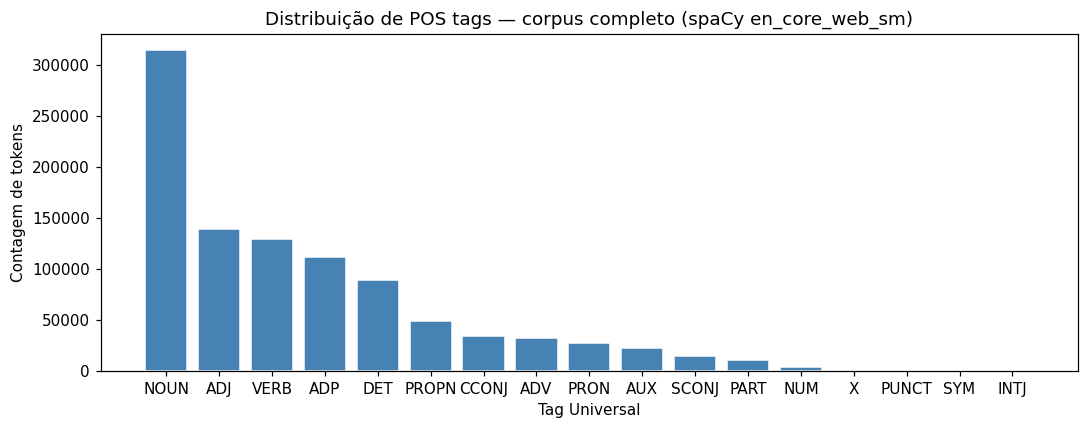


NOUN representa 32.0% de todos os tokens alfa


In [12]:
pos_counts = Counter(
    token.pos_
    for doc in docs
    for token in doc
    if token.is_alpha
)
pos_df = (pd.DataFrame(pos_counts.items(), columns=['POS', 'Frequência'])
            .sort_values('Frequência', ascending=False)
            .reset_index(drop=True))

print(pos_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(pos_df['POS'], pos_df['Frequência'], color='steelblue', edgecolor='white')
ax.set_title('Distribuição de POS tags — corpus completo (spaCy en_core_web_sm)')
ax.set_xlabel('Tag Universal'); ax.set_ylabel('Contagem de tokens')
plt.tight_layout()
plt.savefig('outputs/fig_pos_distribution.png', bbox_inches='tight')
plt.show()

noun_pct = pos_counts['NOUN'] / sum(pos_counts.values()) * 100
print(f'\nNOUN representa {noun_pct:.1f}% de todos os tokens alfa')


## 1.7 Análise de Impacto no Vocabulário


In [13]:
vocab_raw      = len({t for toks in df['tokens_raw']      for t in toks})
vocab_filtered = len({t for toks in df['tokens_filtered']  for t in toks})
vocab_stemmed  = len({t for toks in df['tokens_stemmed']   for t in toks})
vocab_lemma    = len({t for toks in df['tokens_lemma']     for t in toks})

summary = pd.DataFrame({
    'Etapa': [
        'Tokenização bruta (alpha, lower)',
        'Após remoção de stopwords',
        'Após stemming (Porter)',
        'Após lemmatização (spaCy)',
    ],
    'Tokens únicos': [vocab_raw, vocab_filtered, vocab_stemmed, vocab_lemma],
    'Redução vs bruto': [
        '—',
        f'{(1 - vocab_filtered/vocab_raw)*100:.1f}%',
        f'{(1 - vocab_stemmed/vocab_raw)*100:.1f}%',
        f'{(1 - vocab_lemma/vocab_raw)*100:.1f}%',
    ],
})
print(summary.to_string(index=False))


                           Etapa  Tokens únicos Redução vs bruto
Tokenização bruta (alpha, lower)          21835                —
       Após remoção de stopwords          21645             0.9%
          Após stemming (Porter)          13701            37.3%
       Após lemmatização (spaCy)          18931            13.3%


### Interpretação

- **Stopwords** removem os termos de alta frequência e baixo conteúdo. A magnitude depende da fração de hápax (palavras que aparecem uma só vez), que não são afetados pela lista de stopwords.
- **Stemming (Porter)** produz a maior compressão de vocabulário, mas ao custo de legibilidade: raízes como *optim*, *regress* e *distribut* não são palavras interpretáveis. No topic modeling isso geraria tópicos difíceis de comunicar.
- **Lemmatização (spaCy)** oferece compressão moderada com preservação total da legibilidade. O lema *network* (de *networks*, *networking*) é imediatamente compreensível; o mesmo vale para *algorithm*, *learn*, *distribute*.

**Escolha consolidada:** `tokens_lemma` é a representação adotada nas fases 2–5 do pipeline.


## 1.8 Visualizações


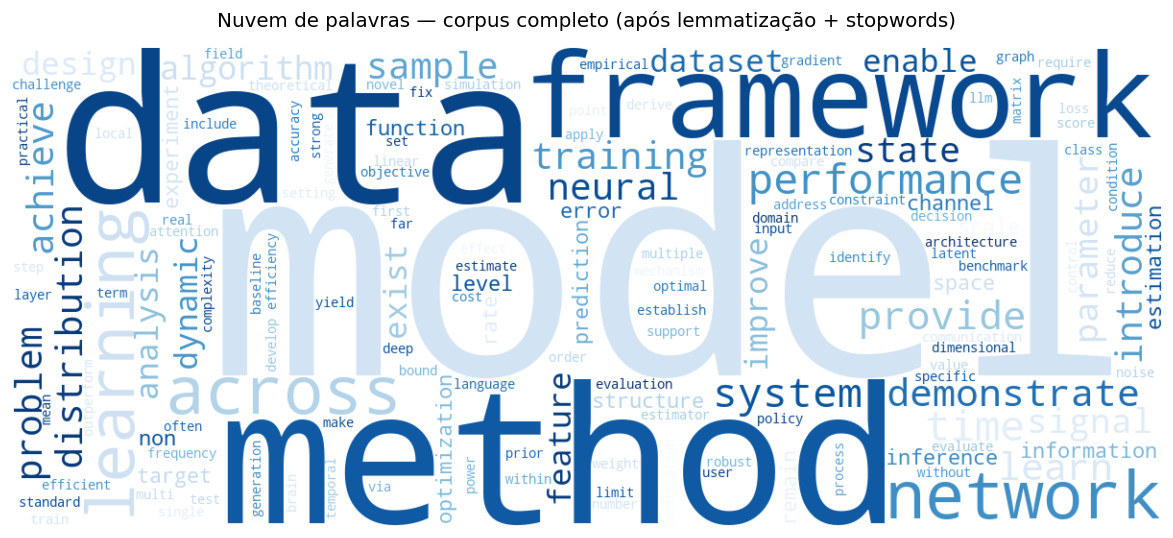

Stopwords de domínio ausentes da nuvem (amostra): ['paper', 'propose', 'result', 'approach', 'show']


In [14]:
all_lemmas = ' '.join(t for toks in df['tokens_lemma'] for t in toks)

wc = WordCloud(
    width=1200, height=500,
    background_color='white',
    max_words=150,
    colormap='Blues_r',
    collocations=False,
).generate(all_lemmas)

fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title(
    'Nuvem de palavras — corpus completo (após lemmatização + stopwords)',
    pad=14, fontsize=13
)
plt.tight_layout()
plt.savefig('outputs/fig_wordcloud.png', bbox_inches='tight')
plt.show()

# Confirm domain stopwords are absent
absent = [t for t in ['paper', 'propose', 'result', 'approach', 'show']
          if t not in all_lemmas.split()[:5000]]
print('Stopwords de domínio ausentes da nuvem (amostra):', absent)


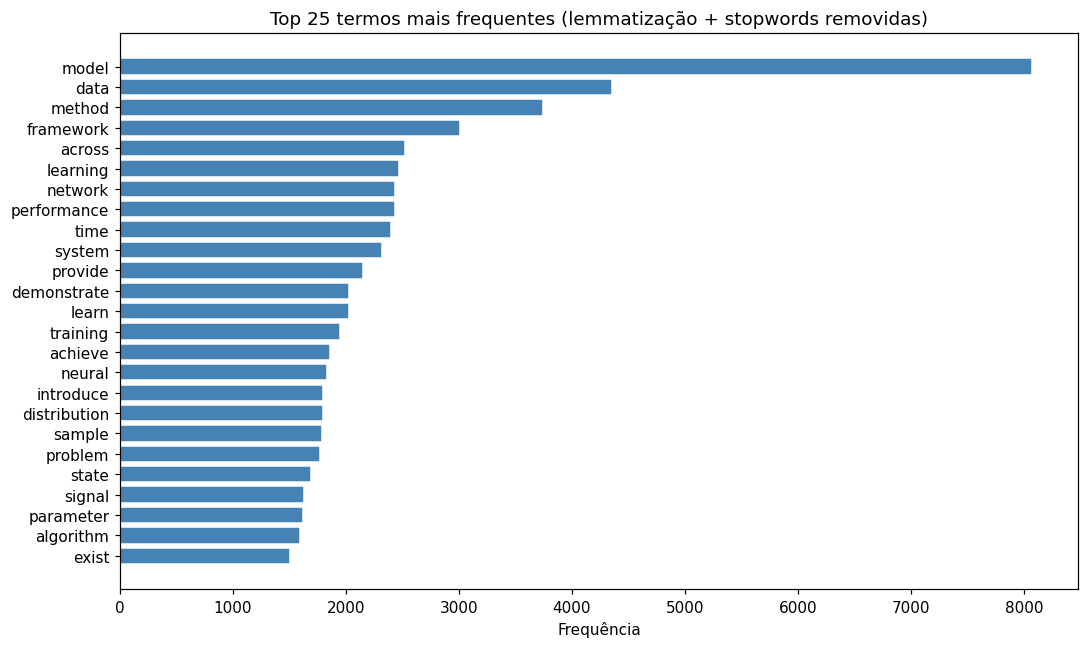

In [15]:
TOP_N = 25
counter = Counter(t for toks in df['tokens_lemma'] for t in toks)
terms, freqs = zip(*counter.most_common(TOP_N))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(TOP_N), freqs[::-1], color='steelblue', edgecolor='white')
ax.set_yticks(range(TOP_N))
ax.set_yticklabels(terms[::-1])
ax.set_title(f'Top {TOP_N} termos mais frequentes (lemmatização + stopwords removidas)')
ax.set_xlabel('Frequência')
plt.tight_layout()
plt.savefig('outputs/fig_top_terms.png', bbox_inches='tight')
plt.show()


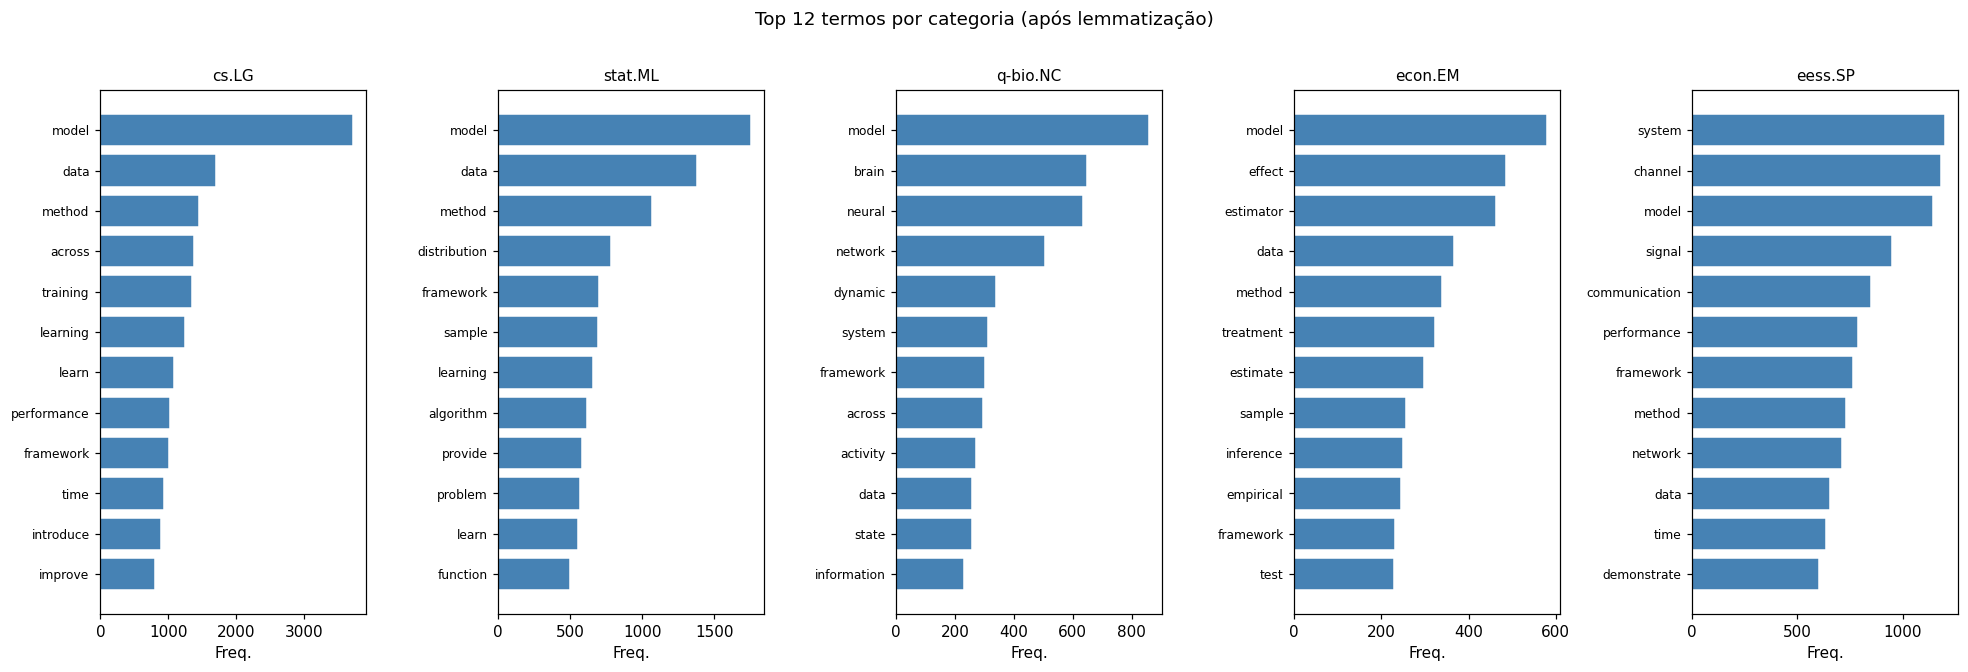

In [16]:
cats = ['cs.LG', 'stat.ML', 'q-bio.NC', 'econ.EM', 'eess.SP']
fig, axes = plt.subplots(1, 5, figsize=(18, 6))

for ax, cat in zip(axes, cats):
    sub = df[df['primary_category'] == cat]['tokens_lemma']
    cnt = Counter(t for toks in sub for t in toks)
    top = cnt.most_common(12)
    ts, fs = zip(*top)
    ax.barh(range(len(ts)), fs[::-1], color='steelblue', edgecolor='white')
    ax.set_yticks(range(len(ts)))
    ax.set_yticklabels(ts[::-1], fontsize=8)
    ax.set_title(cat, fontsize=10)
    ax.set_xlabel('Freq.')

plt.suptitle('Top 12 termos por categoria (após lemmatização)', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig('outputs/fig_top_terms_by_cat.png', bbox_inches='tight')
plt.show()


## Saída da Fase 1

Salvamos o dataframe aumentado com `text_preprocessed` (lemas unidos por espaço)
e `tokens_lemma` (lista de tokens) para evitar re-executar o pipeline spaCy
nas fases seguintes.


In [17]:
df['text_preprocessed'] = df['tokens_lemma'].apply(lambda toks: ' '.join(toks))

cols_out = [
    'id', 'title', 'abstract', 'abstract_clean',
    'primary_category', 'authors', 'published',
    'tokens_lemma', 'text_preprocessed',
]
df[cols_out].to_parquet('data/corpus_preprocessed.parquet', index=False)
print('Salvo: data/corpus_preprocessed.parquet')
print(f'Shape: {df[cols_out].shape}')
print(f'Colunas: {list(df[cols_out].columns)}')


Salvo: data/corpus_preprocessed.parquet
Shape: (5400, 9)
Colunas: ['id', 'title', 'abstract', 'abstract_clean', 'primary_category', 'authors', 'published', 'tokens_lemma', 'text_preprocessed']
